In [1]:
import os

os.listdir()

['.ipynb_checkpoints',
 'Coffee Shop Sales.xlsx',
 'Olist_EDA_Analysis.ipynb',
 '__MACOSX']

In [3]:
import pandas as pd

In [5]:
orders = pd.read_csv("olist_orders_dataset.csv")

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
customers = pd.read_csv("olist_customers_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
category_translation = pd.read_csv("product_category_name_translation.csv")

In [8]:

datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation
}

for name, df in datasets.items():
    print(name, df.shape)

customers (99441, 5)
orders (99441, 8)
order_items (112650, 7)
payments (103886, 5)
reviews (99224, 7)
products (32951, 9)
sellers (3095, 4)
category_translation (71, 2)


In [10]:
# Checking duplicate records in each dataset
# This helps us identify repeated data that could affect our analysis
# Removing unnecessary duplicates ensures more accurate results

for name, df in datasets.items():
    print("\nDataset:", name)
    print("Duplicate rows:", df.duplicated().sum())


Dataset: customers
Duplicate rows: 0

Dataset: orders
Duplicate rows: 0

Dataset: order_items
Duplicate rows: 0

Dataset: payments
Duplicate rows: 0

Dataset: reviews
Duplicate rows: 0

Dataset: products
Duplicate rows: 0

Dataset: sellers
Duplicate rows: 0

Dataset: category_translation
Duplicate rows: 0


In [11]:
# Checking duplicate records in each dataset
# This helps us find repeated data that could affect the accuracy of our analysis
# Identifying duplicates ensures our calculations are based on clean and reliable data

for name, df in datasets.items():
    print("\nDataset:", name)
    print("Duplicate rows:", df.duplicated().sum())


Dataset: customers
Duplicate rows: 0

Dataset: orders
Duplicate rows: 0

Dataset: order_items
Duplicate rows: 0

Dataset: payments
Duplicate rows: 0

Dataset: reviews
Duplicate rows: 0

Dataset: products
Duplicate rows: 0

Dataset: sellers
Duplicate rows: 0

Dataset: category_translation
Duplicate rows: 0


In [12]:
# Checking data types of each dataset
# This helps us understand how each column is stored and identify columns that need conversion
# Correct data types are important for accurate calculations and analysis

for name, df in datasets.items():
    print("\nDataset:", name)
    print(df.dtypes)


Dataset: customers
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

Dataset: orders
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Dataset: order_items
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

Dataset: payments
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: o

In [13]:
# Converting important date columns into datetime format
# This allows us to perform time-based analysis such as sales trends and delivery performance
# Proper date formats help us calculate time differences and create accurate insights

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders[column] = pd.to_datetime(orders[column])

print("Date columns converted successfully")

Date columns converted successfully


In [14]:
# Analyzing the distribution of different order statuses
# This helps us understand overall marketplace performance and order completion rates
# Order status analysis gives insights into operational efficiency and customer experience

order_status_count = orders["order_status"].value_counts()

order_status_count

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [15]:
# Calculating the percentage share of each order status
# This helps us understand the overall order completion rate and operational issues

order_status_percentage = (orders["order_status"].value_counts(normalize=True) * 100).round(2)

order_status_percentage

order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64

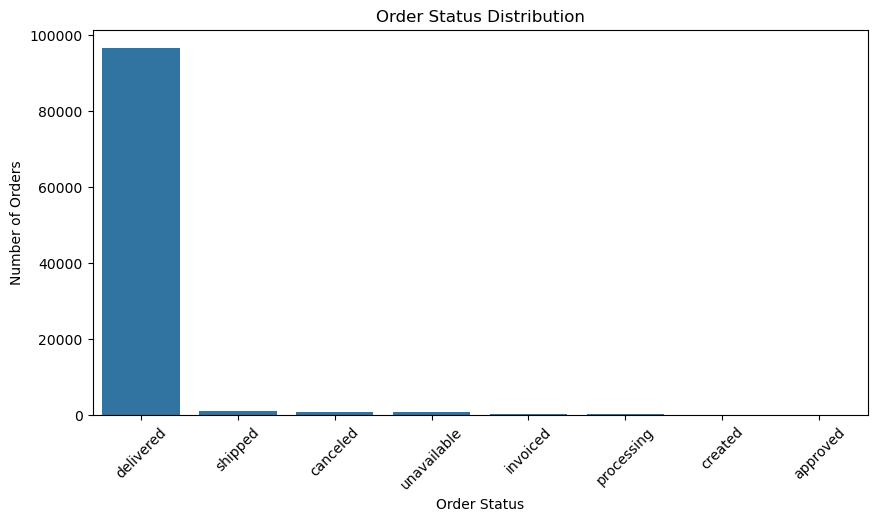

In [16]:
# Visualizing order status distribution
# This chart makes it easier to compare completed orders with other order outcomes
# Visual analysis helps communicate business insights clearly

plt.figure(figsize=(10, 5))

sns.barplot(
    x=order_status_count.index,
    y=order_status_count.values
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

In [17]:
# Calculating key sales performance metrics
# This helps us understand the overall business scale and revenue performance
# These KPIs are commonly used by businesses to measure growth and performance

total_revenue = order_items["price"].sum()

total_orders = orders["order_id"].nunique()

average_order_value = total_revenue / total_orders

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Average Order Value:", round(average_order_value, 2))

Total Revenue: 13591643.7
Total Orders: 99441
Average Order Value: 136.68


In [18]:
# Creating a simple KPI summary for sales performance
# This makes the main business metrics easier to read and present
# These KPIs can also be used later in Power BI dashboard preparation

sales_kpi = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Average Order Value"
    ],
    "Value": [
        total_revenue,
        total_orders,
        average_order_value
    ]
})

sales_kpi

,Metric,Value
0,Total Revenue,1.359164e+07
1,Total Orders,9.944100e+04
2,Average Order Value,1.366805e+02


In [19]:
# Combining order dates with product prices to analyze revenue over time
# This helps us calculate monthly revenue trends and understand business growth patterns

revenue_analysis = order_items.merge(
    orders[["order_id", "order_purchase_timestamp"]],
    on="order_id",
    how="left"
)

# Extracting month and year from order date for trend analysis
revenue_analysis["order_month"] = revenue_analysis["order_purchase_timestamp"].dt.to_period("M")

monthly_revenue = (
    revenue_analysis
    .groupby("order_month")["price"]
    .sum()
)

monthly_revenue

order_month
2016-09        267.36
2016-10      49507.66
2016-12         10.90
2017-01     120312.87
2017-02     247303.02
2017-03     374344.30
2017-04     359927.23
2017-05     506071.14
2017-06     433038.60
2017-07     498031.48
2017-08     573971.68
2017-09     624401.69
2017-10     664219.43
2017-11    1010271.37
2017-12     743914.17
2018-01     950030.36
2018-02     844178.71
2018-03     983213.44
2018-04     996647.75
2018-05     996517.68
2018-06     865124.31
2018-07     895507.22
2018-08     854686.33
2018-09        145.00
Freq: M, Name: price, dtype: float64

In [20]:
# Analyzing monthly order volume to understand customer demand over time
# This helps us identify growth patterns and changes in order activity

monthly_orders = (
    orders
    .assign(order_month=orders["order_purchase_timestamp"].dt.to_period("M"))
    .groupby("order_month")["order_id"]
    .nunique()
)

monthly_orders

order_month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: order_id, dtype: int64

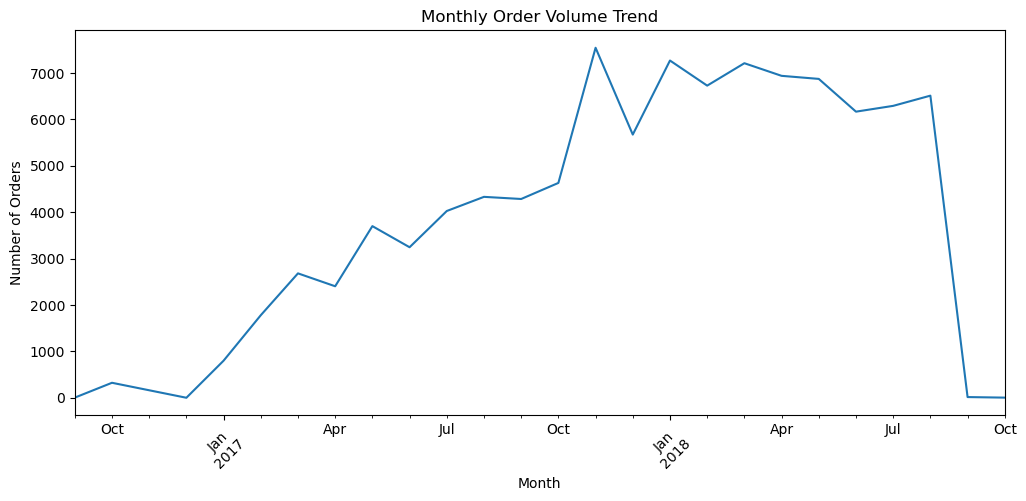

In [21]:
# Visualizing monthly order volume trends
# This helps us understand changes in customer demand and marketplace activity over time

plt.figure(figsize=(12, 5))

monthly_orders.plot()

plt.title("Monthly Order Volume Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

In [22]:
# Analyzing customer distribution by state
# This helps us understand where most customers are located
# Geographic insights can support marketing strategies and business expansion decisions

customer_state_orders = (
    customers
    .groupby("customer_state")["customer_id"]
    .count()
    .sort_values(ascending=False)
)

customer_state_orders

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: customer_id, dtype: int64

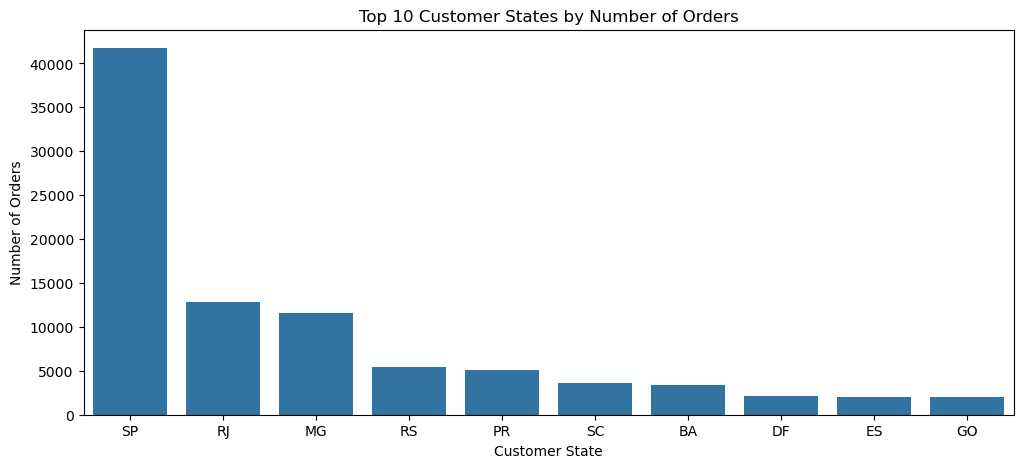

In [23]:
# Visualizing customer distribution across states
# This makes it easier to identify the strongest customer markets
# Geographic charts help communicate business opportunities clearly

plt.figure(figsize=(12, 5))

sns.barplot(
    x=customer_state_orders.head(10).index,
    y=customer_state_orders.head(10).values
)

plt.title("Top 10 Customer States by Number of Orders")
plt.xlabel("Customer State")
plt.ylabel("Number of Orders")

plt.show()

In [24]:
# Combining product details with order revenue data
# This helps us understand which product categories contribute the most to business revenue
# Category-level analysis helps identify important revenue drivers

product_revenue = (
    order_items
    .merge(
        products[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
)

category_revenue = (
    product_revenue
    .groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue.head(10)

product_category_name
beleza_saude              1258681.34
relogios_presentes        1205005.68
cama_mesa_banho           1036988.68
esporte_lazer              988048.97
informatica_acessorios     911954.32
moveis_decoracao           729762.49
cool_stuff                 635290.85
utilidades_domesticas      632248.66
automotivo                 592720.11
ferramentas_jardim         485256.46
Name: price, dtype: float64

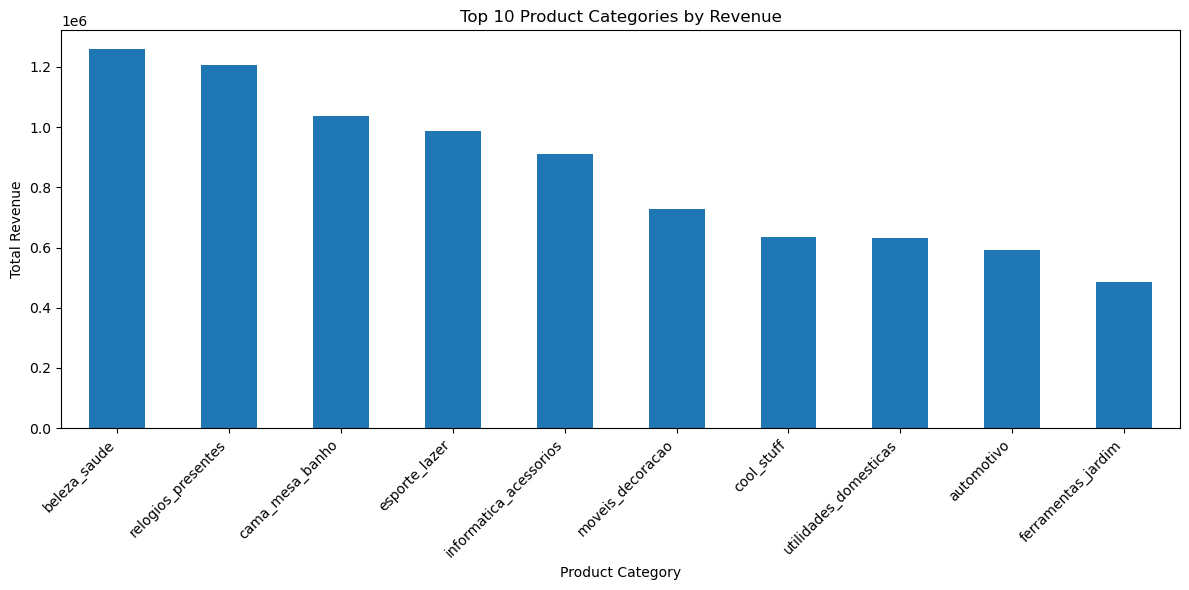

In [25]:
# Select the top 10 product categories by revenue
top_categories = category_revenue.head(10)

# Create a bar chart
plt.figure(figsize=(12, 6))
top_categories.plot(kind="bar")

# Add chart title and labels
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha="right")

# Adjust layout and display the chart
plt.tight_layout()
plt.show()

In [26]:
# Combine order items with orders to get customer information
customer_revenue = (
    order_items
    .merge(
        orders[["order_id", "customer_id"]],
        on="order_id",
        how="left"
    )
)

# Calculate total amount spent by each customer
top_customers = (
    customer_revenue
    .groupby("customer_id")["price"]
    .sum()
    .sort_values(ascending=False)
)

# Display the top 10 customers
top_customers.head(10)

customer_id
1617b1357756262bfa56ab541c47bc16    13440.0
ec5b2ba62e574342386871631fafd3fc     7160.0
c6e2731c5b391845f6800c97401a43a9     6735.0
f48d464a0baaea338cb25f816991ab1f     6729.0
3fd6777bbce08a352fddd04e4a7cc8f6     6499.0
05455dfa7cd02f13d132aa7a6a9729c6     5934.6
df55c14d1476a9a3467f131269c2477f     4799.0
24bbf5fd2f2e1b359ee7de94defc4a15     4690.0
e0a2412720e9ea4f26c1ac985f6a7358     4599.9
3d979689f636322c62418b6346b1c6d2     4590.0
Name: price, dtype: float64

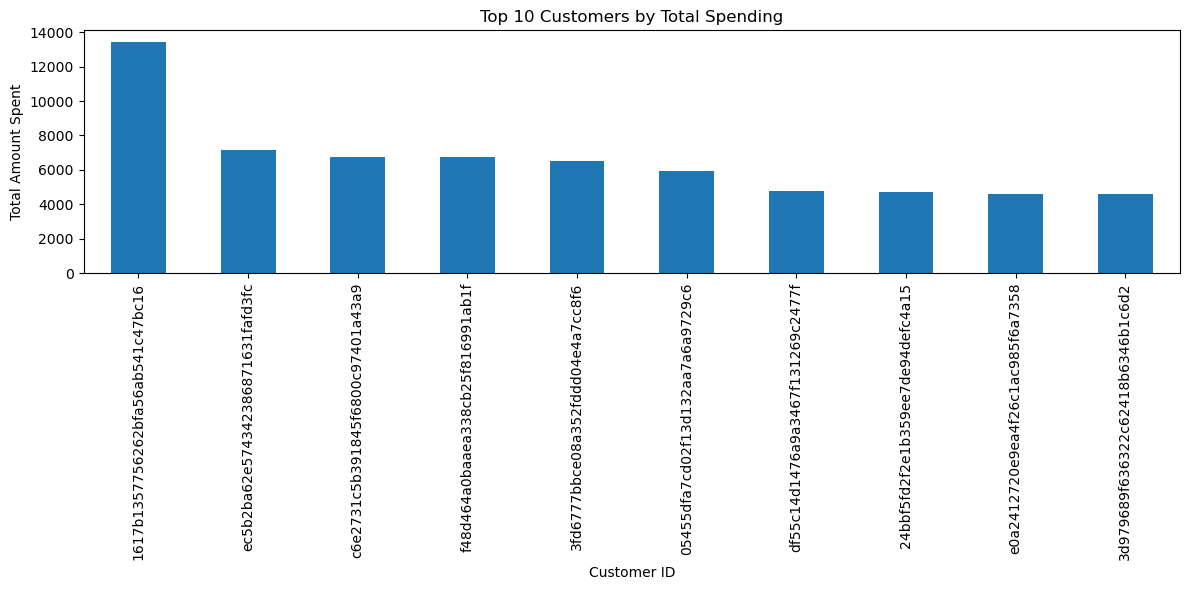

In [27]:
# Select the top 10 customers
top_10_customers = top_customers.head(10)

# Create a bar chart
plt.figure(figsize=(12, 6))
top_10_customers.plot(kind="bar")

# Add chart title and labels
plt.title("Top 10 Customers by Total Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Amount Spent")

# Rotate customer IDs for better readability
plt.xticks(rotation=90)

# Adjust layout and display the chart
plt.tight_layout()
plt.show()

In [28]:
# Count the number of each review score
review_distribution = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
)

# Display the review score distribution
review_distribution

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

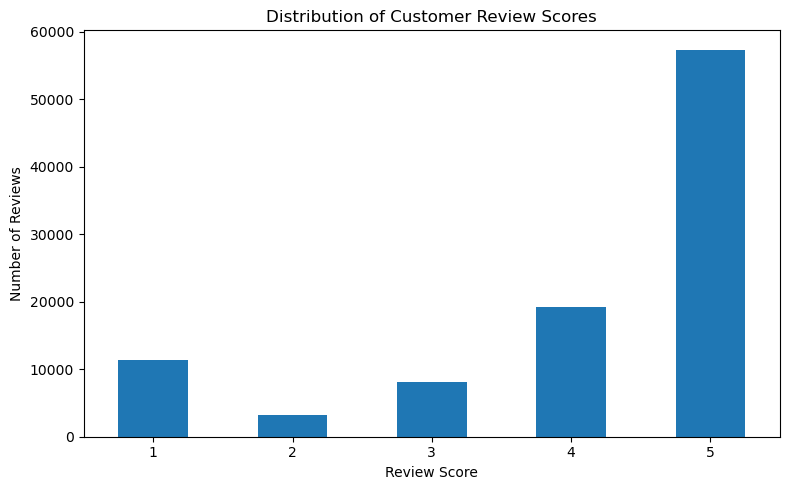

In [29]:
# Create a bar chart for review score distribution
plt.figure(figsize=(8, 5))
review_distribution.plot(kind="bar")

# Add chart title and labels
plt.title("Distribution of Customer Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

# Keep review scores horizontal
plt.xticks(rotation=0)

# Adjust layout and display the chart
plt.tight_layout()
plt.show()

In [32]:
# Convert date columns to datetime format
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])

# Keep only delivered orders
delivered_orders = orders[orders["order_status"] == "delivered"].copy()

# Calculate delivery time in days
delivered_orders["delivery_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_purchase_timestamp"]
).dt.days

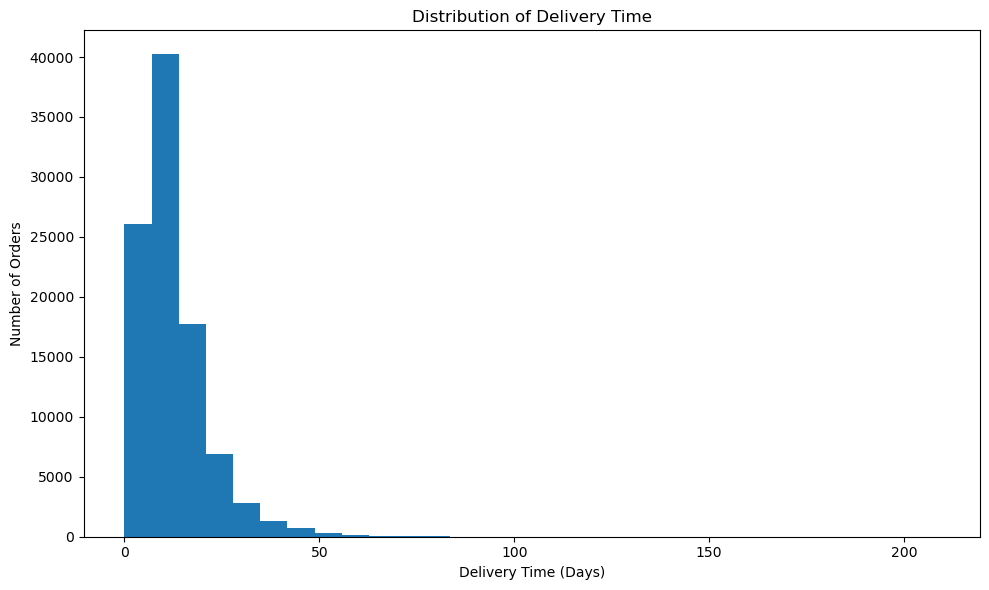

In [33]:
# Create a histogram of delivery times
plt.figure(figsize=(10, 6))
plt.hist(delivered_orders["delivery_days"], bins=30)

# Add chart title and labels
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")

# Display the chart
plt.tight_layout()
plt.show()

In [34]:
# Calculate total revenue generated by each seller
seller_revenue = (
    order_items
    .groupby("seller_id")["price"]
    .sum()
    .sort_values(ascending=False)
)

# Display the top 10 sellers
seller_revenue.head(10)

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    200472.92
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    187923.89
7e93a43ef30c4f03f38b393420bc753a    176431.87
da8622b14eb17ae2831f4ac5b9dab84a    160236.57
7a67c85e85bb2ce8582c35f2203ad736    141745.53
1025f0e2d44d7041d6cf58b6550e0bfa    138968.55
955fee9216a65b617aa5c0531780ce60    135171.70
Name: price, dtype: float64

In [35]:
# Combine order information with order item revenue
monthly_sales = (
    order_items
    .merge(
        orders[["order_id", "order_purchase_timestamp"]],
        on="order_id",
        how="left"
    )
)

# Convert purchase date to datetime format
monthly_sales["order_purchase_timestamp"] = pd.to_datetime(
    monthly_sales["order_purchase_timestamp"]
)

# Extract year and month
monthly_sales["year_month"] = (
    monthly_sales["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

# Calculate total revenue for each month
monthly_revenue = (
    monthly_sales
    .groupby("year_month")["price"]
    .sum()
    .sort_index()
)

# Display the monthly revenue
monthly_revenue

year_month
2016-09        267.36
2016-10      49507.66
2016-12         10.90
2017-01     120312.87
2017-02     247303.02
2017-03     374344.30
2017-04     359927.23
2017-05     506071.14
2017-06     433038.60
2017-07     498031.48
2017-08     573971.68
2017-09     624401.69
2017-10     664219.43
2017-11    1010271.37
2017-12     743914.17
2018-01     950030.36
2018-02     844178.71
2018-03     983213.44
2018-04     996647.75
2018-05     996517.68
2018-06     865124.31
2018-07     895507.22
2018-08     854686.33
2018-09        145.00
Name: price, dtype: float64

In [36]:
# Count the number of orders for each order status
order_status = (
    orders["order_status"]
    .value_counts()
)

# Display the order status distribution
order_status

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

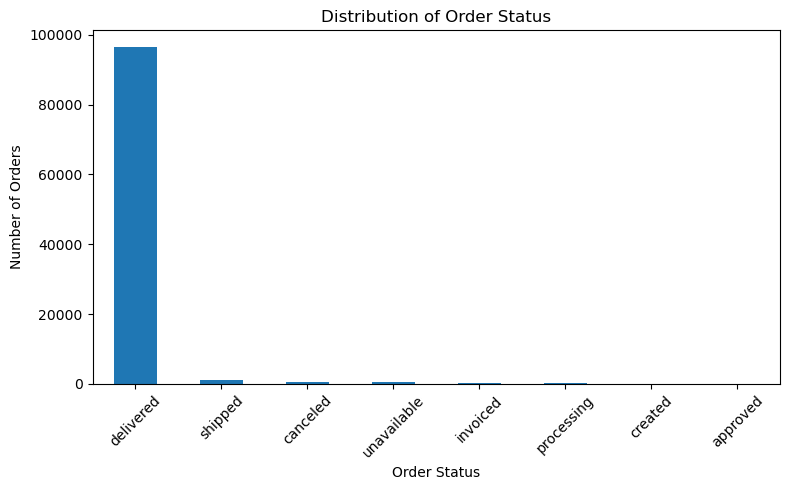

In [37]:
# Create a bar chart for order status distribution
plt.figure(figsize=(8, 5))
order_status.plot(kind="bar")

# Add chart title and labels
plt.title("Distribution of Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display the chart
plt.tight_layout()
plt.show()

In [38]:
# Count the number of orders for each payment type
payment_distribution = (
    payments["payment_type"]
    .value_counts()
)

# Display the payment method distribution
payment_distribution

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

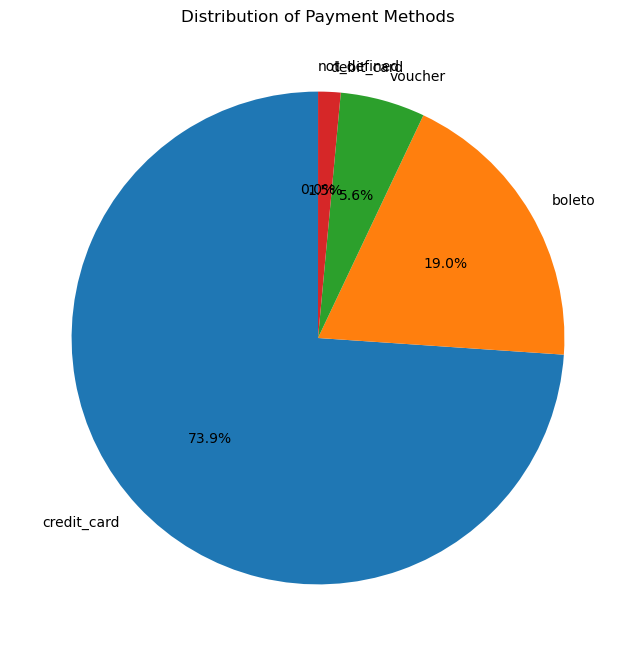

In [39]:
# Create a pie chart for payment method distribution
plt.figure(figsize=(8, 8))

plt.pie(
    payment_distribution,
    labels=payment_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

# Add chart title
plt.title("Distribution of Payment Methods")

# Display the chart
plt.show()

In [40]:
# Calculate total revenue for each payment method
payment_revenue = (
    payments
    .groupby("payment_type")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

# Display total revenue by payment method
payment_revenue

payment_type
credit_card    12542084.19
boleto          2869361.27
voucher          379436.87
debit_card       217989.79
not_defined           0.00
Name: payment_value, dtype: float64

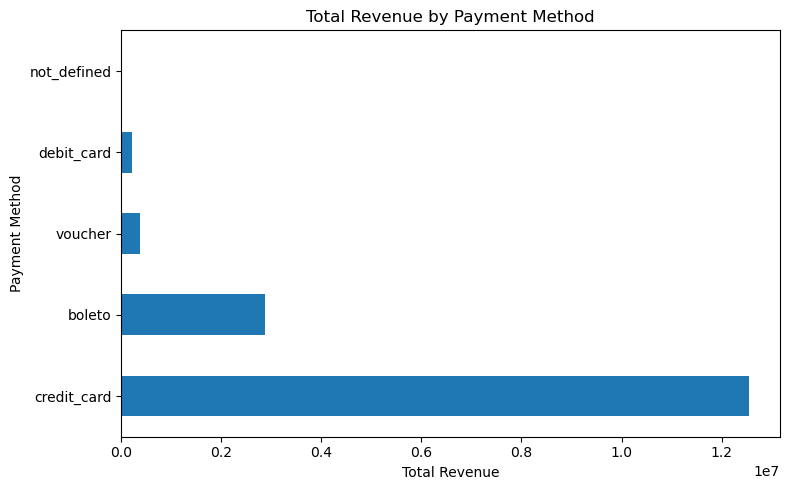

In [41]:
# Create a horizontal bar chart
plt.figure(figsize=(8, 5))

payment_revenue.plot(kind="barh")

# Add chart title and labels
plt.title("Total Revenue by Payment Method")
plt.xlabel("Total Revenue")
plt.ylabel("Payment Method")

# Display the chart
plt.tight_layout()
plt.show()

In [44]:
# Merge orders with reviews
delivery_reviews = (
    delivered_orders
    .merge(
        reviews[["order_id", "review_score"]],
        on="order_id",
        how="inner"
    )
)

# Calculate average delivery time for each review score
avg_delivery_review = (
    delivery_reviews
    .groupby("review_score")["delivery_days"]
    .mean()
    .reset_index()
)

# Display the results
avg_delivery_review

,review_score,delivery_days
0,1,20.849973
1,2,16.194832
2,3,13.793242
3,4,11.848054
4,5,10.224154


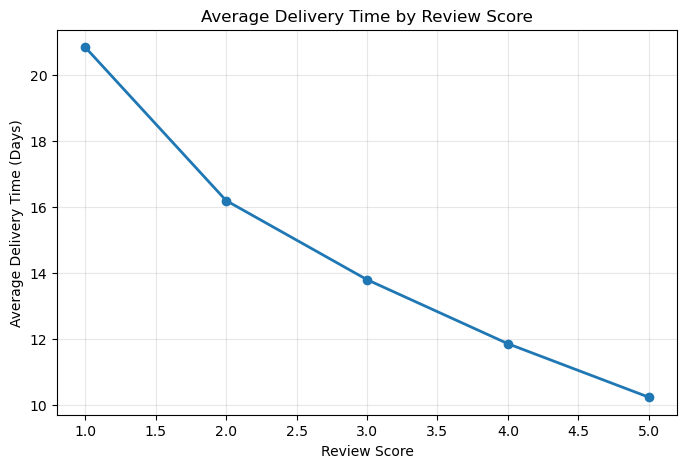

In [47]:
plt.figure(figsize=(8,5))

plt.plot(
    avg_delivery_review["review_score"],
    avg_delivery_review["delivery_days"],
    marker="o",
    linewidth=2
)

plt.title("Average Delivery Time by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delivery Time (Days)")

plt.grid(alpha=0.3)
plt.show()

In [48]:
# Count the number of orders placed each month
monthly_orders = (
    orders
    .copy()
)

# Convert purchase timestamp to datetime
monthly_orders["order_purchase_timestamp"] = pd.to_datetime(
    monthly_orders["order_purchase_timestamp"]
)

# Extract year and month
monthly_orders["year_month"] = (
    monthly_orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

# Calculate monthly order count
monthly_order_count = (
    monthly_orders
    .groupby("year_month")["order_id"]
    .count()
)

# Combine monthly revenue and monthly order count
monthly_summary = (
    monthly_revenue.to_frame(name="Revenue")
    .join(monthly_order_count.to_frame(name="Orders"))
)

# Display the result
monthly_summary

,Revenue,Orders
year_month,,
2016-09,267.36,4
2016-10,49507.66,324
2016-12,10.90,1
2017-01,120312.87,800
2017-02,247303.02,1780
2017-03,374344.30,2682
2017-04,359927.23,2404
2017-05,506071.14,3700
2017-06,433038.60,3245


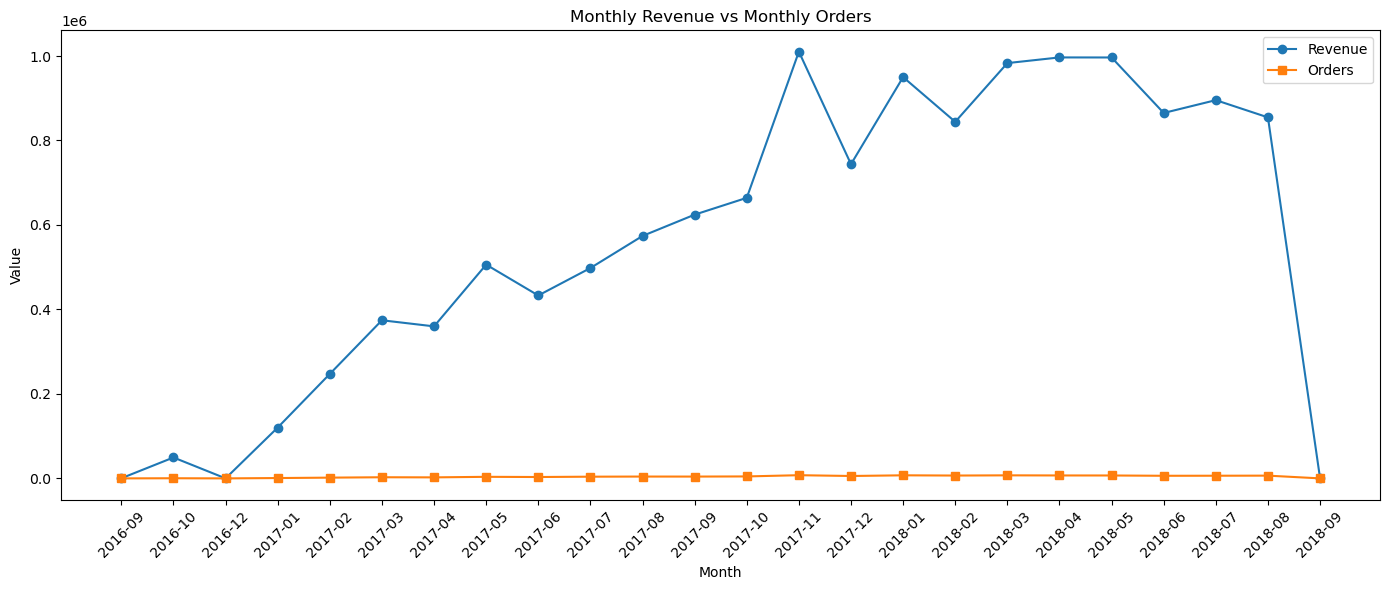

In [49]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_summary.index,
    monthly_summary["Revenue"],
    marker="o",
    label="Revenue"
)

plt.plot(
    monthly_summary.index,
    monthly_summary["Orders"],
    marker="s",
    label="Orders"
)

plt.title("Monthly Revenue vs Monthly Orders")
plt.xlabel("Month")
plt.ylabel("Value")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [50]:
# Calculate total amount spent by each customer
customer_summary = (
    order_items
    .merge(
        orders[["order_id", "customer_id"]],
        on="order_id",
        how="left"
    )
    .groupby("customer_id")
    .agg(
        Total_Orders=("order_id", "nunique"),
        Total_Spent=("price", "sum")
    )
    .sort_values("Total_Spent", ascending=False)
)

# Display the top 5 customers
customer_summary.head(5)

,Total_Orders,Total_Spent
customer_id,,
1617b1357756262bfa56ab541c47bc16,1,13440.0
ec5b2ba62e574342386871631fafd3fc,1,7160.0
c6e2731c5b391845f6800c97401a43a9,1,6735.0
f48d464a0baaea338cb25f816991ab1f,1,6729.0
3fd6777bbce08a352fddd04e4a7cc8f6,1,6499.0


In [ ]:
#Business Recommendations

# Focus marketing efforts on high-performing product categories.

# Strengthen relationships with top-performing sellers.

# Improve delivery times to increase customer satisfaction.

# Encourage customers to increase their average order value through bundle offers and free shipping thresholds.

# Continue investing in regions generating the highest revenue.

In [ ]:
#Project Conclusion

#This project analyzed the Brazilian Olist e-commerce dataset using Python and Pandas.

#Key findings include:
# Beauty and watches were among the highest revenue-generating product categories.
# Credit cards were the preferred payment method.
# Most customers provided positive reviews.
# Faster deliveries were associated with higher review scores.
# Monthly revenue showed clear growth trends over time.

# The analysis demonstrates skills in data cleaning, exploratory data analysis, data visualization, KPI reporting, and business storytelling using Python.